In [56]:
!python -m pip install kaggle



[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [57]:
!python -m kaggle datasets list -s diabetes


c:\Users\Nassima.OUKHELIFA\AppData\Local\Programs\Python\Python312\python.exe: No module named kaggle.__main__; 'kaggle' is a package and cannot be directly executed


In [58]:
import os
os.environ['PATH'] += os.pathsep + r'C:\Users\Nassima.OUKHELIFA\AppData\Local\Programs\Python\Python312\Scripts'

!kaggle --version


Kaggle API 1.7.4.5


In [59]:
!kaggle datasets download -d uciml/pima-indians-diabetes-database


Dataset URL: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
License(s): CC0-1.0
pima-indians-diabetes-database.zip: Skipping, found more recently modified local copy (use --force to force download)


In [60]:
import zipfile

with zipfile.ZipFile("pima-indians-diabetes-database.zip", "r") as zip_ref:
    zip_ref.extractall("data")


In [61]:
import pandas as pd

df = pd.read_csv("data/diabetes.csv")
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [62]:
# Nombre de lignes et de colonnes
print("Dimensions du dataset :", df.shape)

# Aperçu des types de données
df.info()


Dimensions du dataset : (768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


* Étape 1 – Vérification des valeurs nulles ou anormales

Certaines colonnes du dataset ne contiennent pas de valeurs manquantes au sens strict (aucun NaN),
mais elles peuvent inclure des valeurs nulles (0) qui n’ont pas de sens physiologique.
Par exemple :

une glycémie (Glucose) égale à 0 n’est pas possible,

un indice de masse corporelle (BMI) ou une pression artérielle à 0 non plus.

 L’objectif ici est d’identifier ces cas afin de décider s’il faut :

les remplacer (par la moyenne, médiane ou autre),

ou les exclure du jeu de données.

In [63]:
# Colonnes où 0 n’a pas de sens (pas une vraie mesure)
cols_zero_possible = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Nombre de zéros par colonne
(df[cols_zero_possible] == 0).sum()


Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

* Étape 2 – Nettoyage des valeurs anormales

Les colonnes suivantes contiennent des valeurs nulles (0) qui faussent l’analyse statistique.
Nous allons les remplacer par la médiane de chaque colonne, car :

la médiane est robuste aux valeurs extrêmes,

et le dataset contient plusieurs outliers (valeurs extrêmes possibles).

L’objectif est de rendre les distributions plus réalistes avant de calculer les statistiques ou les corrélations.

In [64]:
# Liste des colonnes concernées
cols_zero_possible = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Remplacement des 0 par la médiane de chaque colonne
for col in cols_zero_possible:
    median_value = df[col].median()
    df[col] = df[col].replace(0, median_value)

# Vérifions que les 0 ont bien disparu
(df[cols_zero_possible] == 0).sum()


Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

* Étape 3 – Exploration statistique du dataset

Maintenant que les données sont nettoyées, nous allons examiner leur distribution et leurs statistiques descriptives.
Cela permet de :

comprendre les ordres de grandeur des variables, 
repérer d’éventuelles asymétries (skewness), 
et observer les différences entre les patient·es diabétiques et non-diabétiques.

In [65]:
# Statistiques descriptives générales
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,27.334635,94.652344,32.450911,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,9.229014,105.547598,6.875366,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,23.000000,30.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,31.250000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


* Étape 4 – Visualisation avancée des distributions

Les histogrammes précédents donnent une vue d’ensemble, mais nous allons maintenant tracer des graphiques plus sophistiqués :

Meilleure esthétique avec seaborn,

Histogrammes + courbes de densité,

Palette de couleurs cohérente,

Titres et mise en page claire.

Ces visualisations permettront d’identifier les variables asymétriques, bimodales ou présentant des valeurs extrêmes.


C:\Users\Nassima.OUKHELIFA\AppData\Local\Temp\ipykernel_51500\3508695430.py:21: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Nassima.OUKHELIFA\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


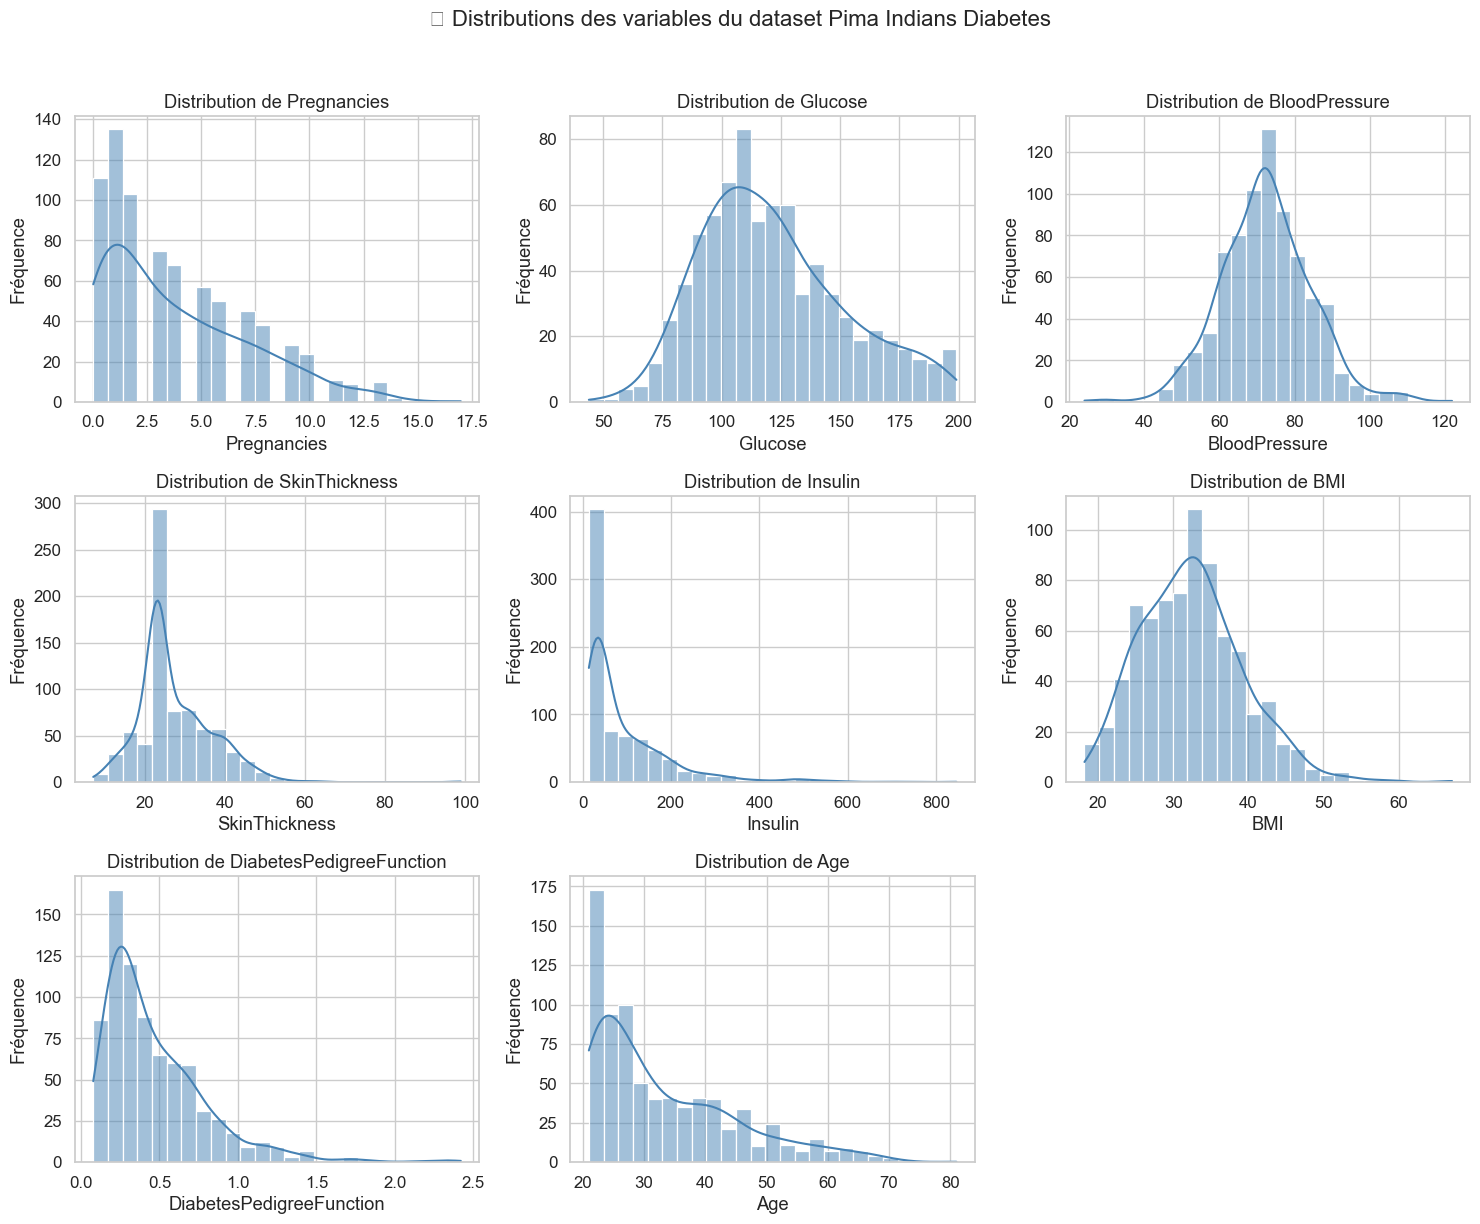

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style plus professionnel
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

# Liste des colonnes numériques (sauf la cible "Outcome")
cols = df.columns[:-1]

# Création d'une grille de sous-graphes
plt.figure(figsize=(15, 12))

for i, col in enumerate(cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, bins=25, color="steelblue")
    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")

plt.suptitle("📊 Distributions des variables du dataset Pima Indians Diabetes", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


C:\Users\Nassima.OUKHELIFA\AppData\Local\Temp\ipykernel_51500\3041032487.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Outcome", y=col, data=df, palette="coolwarm")
C:\Users\Nassima.OUKHELIFA\AppData\Local\Temp\ipykernel_51500\3041032487.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Outcome", y=col, data=df, palette="coolwarm")
C:\Users\Nassima.OUKHELIFA\AppData\Local\Temp\ipykernel_51500\3041032487.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Outcome", y=col, data=df, palette="coolwarm")
C:\Users\Nassima.OUKHE

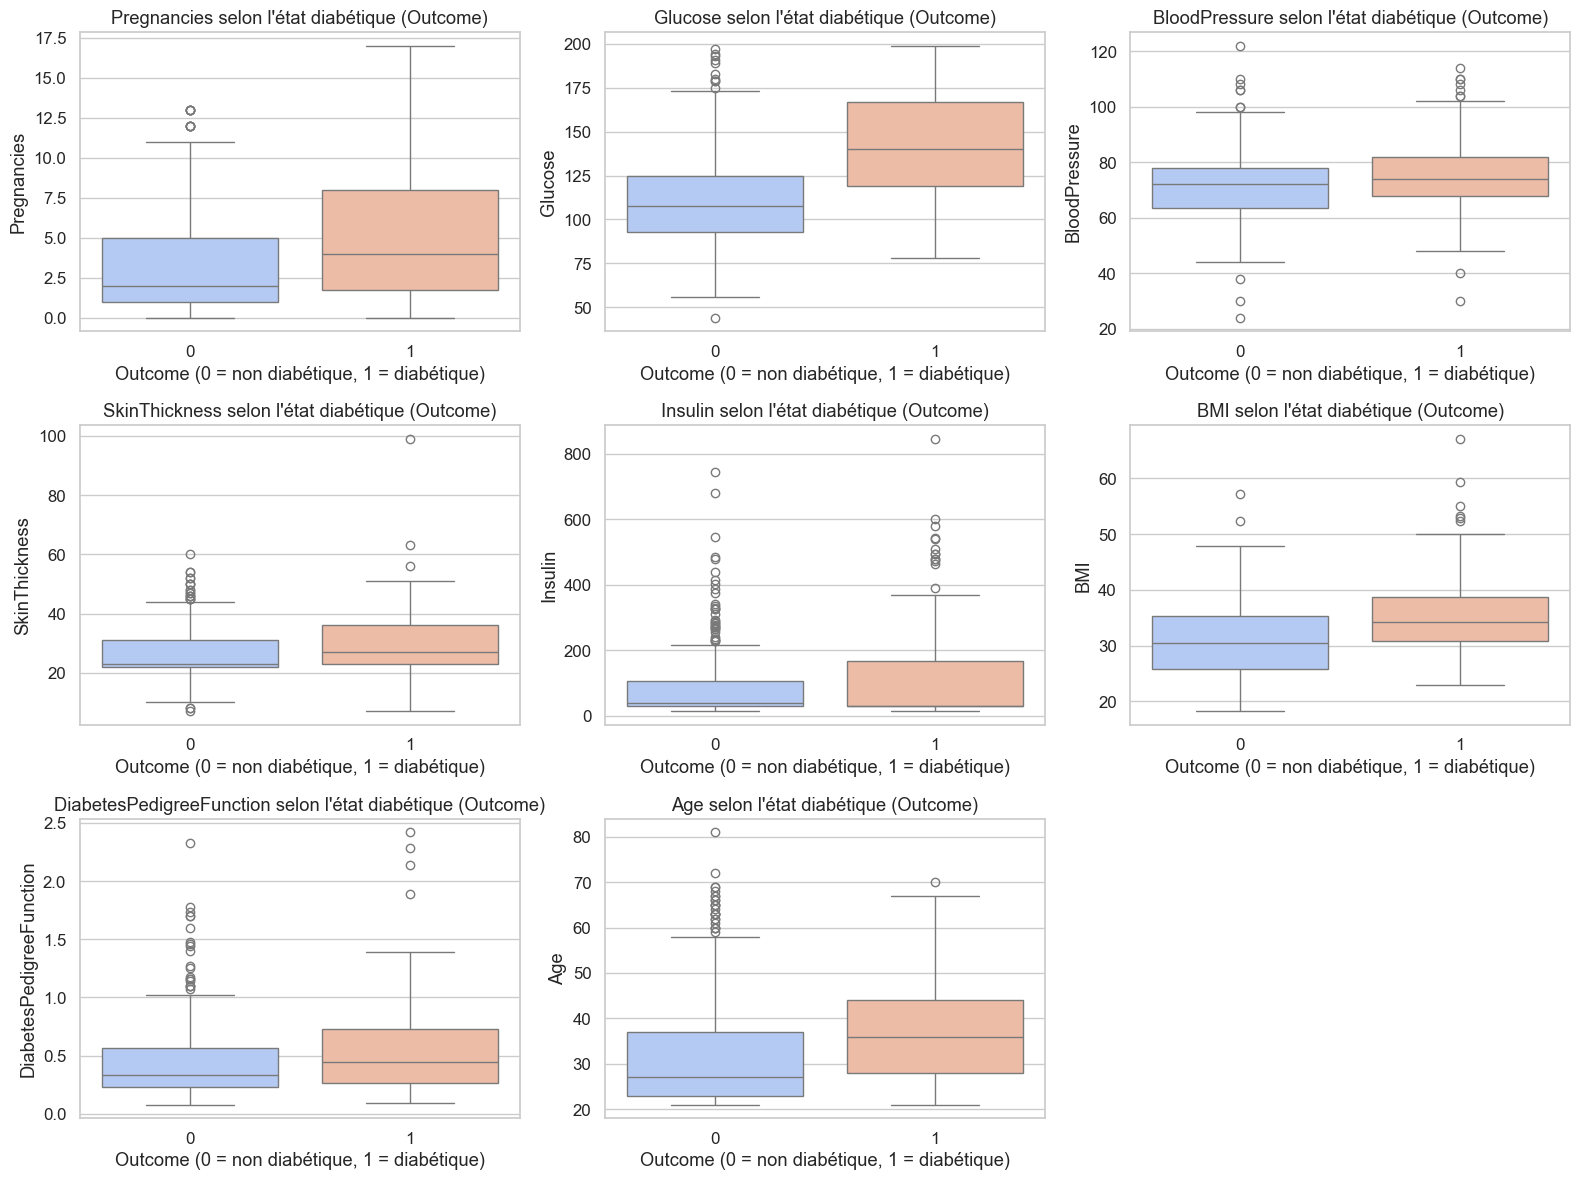

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
            "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

plt.figure(figsize=(16, 12))

for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x="Outcome", y=col, data=df, palette="coolwarm")
    plt.title(f"{col} selon l'état diabétique (Outcome)")
    plt.xlabel("Outcome (0 = non diabétique, 1 = diabétique)")
    plt.ylabel(col)

plt.tight_layout()
plt.show()


##  Analyse des variables selon l’état diabétique (`Outcome`)

Les graphiques ci-dessous comparent la distribution de chaque variable entre les deux groupes :
- **0** → patientes non diabétiques (en bleu)  
- **1** → patientes diabétiques (en orange)

L’objectif est d’identifier les variables dont les valeurs sont significativement plus élevées chez les patientes diabétiques, et donc de repérer les **facteurs de risque potentiels**.



###  1. Pregnancies (nombre de grossesses)
- La médiane est légèrement plus élevée chez les patientes diabétiques.  
- Cela suggère que les femmes ayant eu davantage de grossesses peuvent présenter un risque accru de diabète (notamment le diabète gestationnel).

 **Interprétation :**  
Le nombre de grossesses n’est pas la cause directe du diabète, mais il peut être un **facteur aggravant** chez certaines patientes.



###  2. Glucose (glycémie)
- Différence nette entre les deux groupes : la médiane du glucose est beaucoup plus élevée chez les diabétiques.  
- C’est le **facteur le plus discriminant** du dataset.

 **Interprétation :**  
Une glycémie élevée est directement associée au diagnostic du diabète.  
C’est **la variable la plus importante** pour prédire l’`Outcome`.



###  3. BloodPressure (pression artérielle)
- Les deux groupes présentent des distributions très proches.  
- Aucune différence majeure visible.

 **Interprétation :**  
La pression artérielle ne semble pas être un facteur explicatif du diabète dans ce jeu de données, bien qu’elle soit souvent liée à d’autres pathologies métaboliques.



###  4. SkinThickness (épaisseur du pli cutané)
- La boîte des diabétiques est légèrement plus haute, mais la dispersion est importante.  

 **Interprétation :**  
Les patientes diabétiques tendent à avoir un peu plus de masse graisseuse sous-cutanée, mais cette relation reste **faible et instable**.



###  5. Insulin (taux d’insuline)
- Beaucoup de valeurs extrêmes (grande variabilité).  
- La médiane est plus élevée chez les diabétiques.

 **Interprétation :**  
Les patientes diabétiques présentent souvent une **résistance à l’insuline**, entraînant des taux plus élevés.  
Cependant, cette mesure est **bruyante** et doit être utilisée avec précaution.



###  6. BMI (Indice de Masse Corporelle)
- Différence claire : les diabétiques ont un BMI plus élevé (souvent >30).  

 **Interprétation :**  
Le surpoids est un **facteur de risque majeur** du diabète de type 2.  
Cette relation est évidente dans les données.



###  7. DiabetesPedigreeFunction (risque génétique)
- La médiane est légèrement plus élevée chez les diabétiques.  

 **Interprétation :**  
Le facteur héréditaire semble jouer un rôle modéré, sans être prédominant dans ce dataset.



###  8. Age
- Les patientes diabétiques sont globalement plus âgées.  

 **Interprétation :**  
L’âge est un **facteur aggravant** : le risque de diabète augmente clairement après 40 ans.


##  Synthèse générale

| Variable | Lien avec le diabète | Interprétation |
|-----------|----------------------|----------------|
| **Glucose** | 🔥 Très fort | Directement lié au diagnostic du diabète |
| **BMI** | 🔥 Fort | Le surpoids augmente fortement le risque |
| **Age** | 🔥 Fort | Le risque croît avec l’âge |
| **Insulin** | ⚠️ Moyen | Corrélation moyenne, mesure instable |
| **Pregnancies** | ⚠️ Moyen | Facteur hormonal secondaire |
| **SkinThickness** | ⚪ Faible | Influence limitée |
| **BloodPressure** | ⚪ Faible | Peu de différence |
| **DiabetesPedigreeFunction** | ⚪ Faible | Facteur héréditaire modéré |



###  Conclusion visuelle

Les patientes diabétiques présentent en moyenne :
- une **glycémie (Glucose)** plus élevée,  
- un **indice de masse corporelle (BMI)** plus fort,  
- un **âge** plus avancé,  
- et parfois davantage de **grossesses**.

Ces trois premières variables (`Glucose`, `BMI`, `Age`) apparaissent comme les **principaux facteurs associés au diabète** dans le dataset Pima Indians Diabetes.



## 🔗 Étape 6 – Analyse des corrélations entre les variables

L’objectif de cette étape est de **mesurer les relations linéaires** entre les différentes variables du dataset,  
et plus particulièrement de voir **quelles variables sont corrélées avec `Outcome`** (la présence du diabète).

La **corrélation** mesure à quel point deux variables évoluent ensemble :
- une corrélation **positive (proche de +1)** signifie que lorsque l’une augmente, l’autre a tendance à augmenter aussi.
- une corrélation **négative (proche de -1)** signifie que lorsque l’une augmente, l’autre tend à diminuer.
- une corrélation **proche de 0** indique qu’il n’y a pas de relation linéaire claire.

Nous allons visualiser ces relations sous forme de **carte de chaleur (heatmap)**.
Cela permettra d’identifier les variables les plus fortement reliées entre elles et à la variable `Outcome`.




C:\Users\Nassima.OUKHELIFA\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


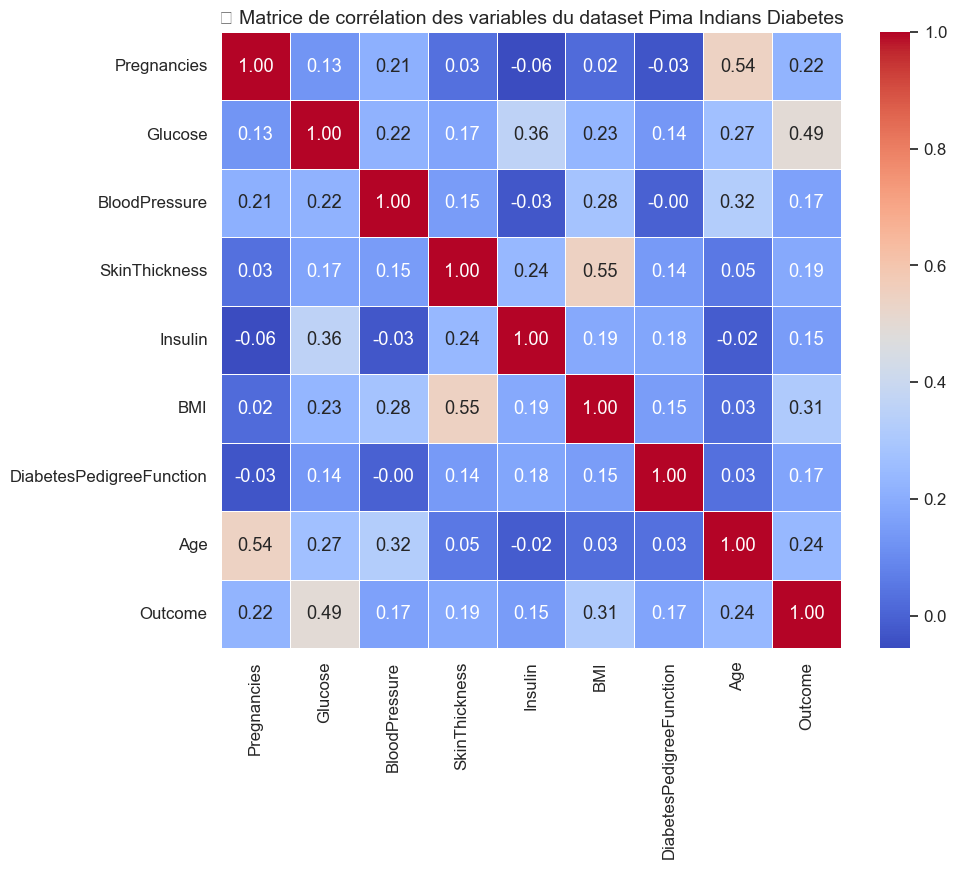

In [68]:


###  Code – Matrice de corrélation
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("🔗 Matrice de corrélation des variables du dataset Pima Indians Diabetes", fontsize=14)
plt.show()

##  Interprétation de la matrice de corrélation

La matrice ci-dessus montre les **corrélations linéaires** entre toutes les variables du dataset Pima Indians Diabetes.  
Les valeurs vont de **-1 (corrélation négative)** à **+1 (corrélation positive)** :
- Plus la couleur est **rouge**, plus la corrélation est **forte et positive**.
- Plus la couleur est **bleue**, plus la corrélation est **faible ou négative**.



###  Corrélation des variables avec `Outcome` (le diabète)

| Variable | Corrélation avec `Outcome` | Interprétation |
|-----------|----------------------------|----------------|
| **Glucose** | **0.49** | C’est la corrélation la plus forte. Plus la glycémie est élevée, plus le risque de diabète est grand. |
| **BMI** | **0.31** | Le surpoids et l’obésité augmentent clairement la probabilité d’être diabétique. |
| **Age** | **0.24** | Le risque de diabète croît avec l’âge. |
| **Pregnancies** | **0.22** | Les femmes ayant eu plus de grossesses ont un risque légèrement plus élevé. |
| **SkinThickness** | **0.19** | Corrélation modérée, liée à la masse graisseuse. |
| **BloodPressure** | **0.17** | Corrélation faible, peu d’impact direct. |
| **Insulin** | **0.15** | Légère corrélation, mais mesure très variable. |
| **DiabetesPedigreeFunction** | **0.17** | Corrélation faible, facteur génétique secondaire. |



###  Corrélations intéressantes entre variables

- **SkinThickness** et **BMI** : corrélation de **0.55** → plus une personne a de masse graisseuse, plus l’épaisseur du pli cutané est élevée.  
- **Age** et **Pregnancies** : corrélation de **0.54** → logique, les femmes plus âgées ont eu plus d’occasions d’avoir des grossesses.  
- **Glucose** et **Insulin** : corrélation modérée (**0.36**) → une glycémie élevée est souvent associée à une réponse insulinique importante.



###  Interprétation globale

Les variables les plus corrélées à `Outcome` sont :
- **Glucose (0.49)** : facteur principal et direct du diabète.  
- **BMI (0.31)** : le surpoids joue un rôle majeur.  
- **Age (0.24)** et **Pregnancies (0.22)** : effets secondaires mais cohérents.

Les autres variables (pression artérielle, insuline, épaisseur du pli cutané, risque génétique) présentent des corrélations plus faibles.



###  Conclusion

La heatmap confirme que le diabète est **principalement lié à des facteurs métaboliques** :
- **Glycémie élevée (Glucose)**,  
- **Surpoids (BMI)**,  
- **Âge plus avancé (Age)**.

Ces trois variables seront donc **les plus importantes** pour la modélisation prédictive dans la suite de l’analyse.


##  Étape 7 – Modélisation prédictive : Régression logistique

###  Objectif
Nous allons construire un **modèle de régression logistique** pour prédire la probabilité qu’une personne soit diabétique (`Outcome = 1`)  
à partir des variables explicatives (`Glucose`, `BMI`, `Age`, etc.).

La régression logistique est un modèle de classification qui :
- estime la **probabilité** d’appartenir à une classe (ici diabétique ou non),
- attribue un **poids** à chaque variable (positif ou négatif) selon son influence.



###  Étapes du modèle
1. **Séparation des variables**  
   - `X` = variables explicatives  
   - `y` = variable cible (`Outcome`)
2. **Découpage des données** en jeu d’entraînement et de test  
3. **Entraînement du modèle** de régression logistique  
4. **Évaluation** des performances (précision, matrice de confusion, etc.)
5. **Interprétation** des coefficients pour comprendre quelles variables ont le plus d’impact.



* Précision du modèle : 0.70

* Rapport de classification :
               precision    recall  f1-score   support

           0       0.75      0.80      0.78       100
           1       0.58      0.52      0.55        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.69      0.70      0.70       154



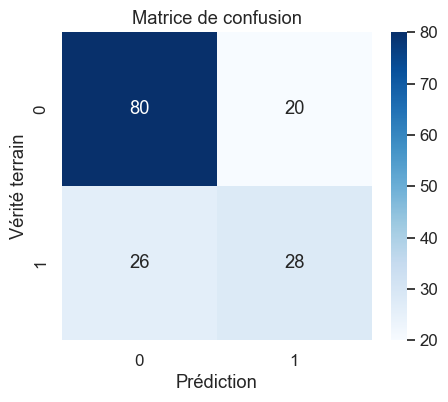

In [69]:


###  Code – Modélisation

# Importation des bibliothèques
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1️⃣ Variables explicatives (X) et cible (y)
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# 2️⃣ Séparation en jeu d'entraînement et de test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3️⃣ Entraînement du modèle
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 4️⃣ Prédictions
y_pred = model.predict(X_test)

# 5️⃣ Évaluation
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"* Précision du modèle : {accuracy:.2f}")
print("\n* Rapport de classification :\n", report)

# 6️⃣ Visualisation de la matrice de confusion
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion")
plt.xlabel("Prédiction")
plt.ylabel("Vérité terrain")
plt.show()



## 📉 Interprétation de la matrice de confusion

|                | **Prédit : 0** | **Prédit : 1** |
|----------------|----------------|----------------|
| **Réel : 0** (non diabétique) | **80** | **20** |
| **Réel : 1** (diabétique)     | **26** | **28** |



### 🧠 Lecture
- **80** → non-diabétiques bien identifiées (**vrais négatifs**)  
- **28** → diabétiques bien détectées (**vrais positifs**)  
- **20** → faux positifs (le modèle “surestime” un peu le diabète)  
- **26** → faux négatifs (le modèle “oublie” certains diabétiques)



### 💬 Interprétation
- Le modèle **identifie bien les patientes non diabétiques** (80 sur 100).  
- En revanche, il **manque environ la moitié des patientes diabétiques** (26 sur 54 non détectées).  

Cela montre un **rappel plus faible pour la classe 1 (diabétiques)**.



### ⚖️ Conséquence
- Les **faux positifs** entraînent de fausses alertes (acceptables médicalement).  
- Les **faux négatifs** sont plus problématiques : des patientes diabétiques non détectées.  

Le modèle est donc **prudent** mais **pas encore assez sensible** pour repérer tous les cas de diabète.


### 💡 Améliorations possibles
- Utiliser `class_weight='balanced'` dans `LogisticRegression` pour mieux traiter le déséquilibre entre classes.  
- Tester des modèles plus puissants comme **Random Forest**, **Gradient Boosting**, ou **XGBoost**.  
- Optimiser le **seuil de probabilité** pour favoriser la détection des vrais diabétiques.


## 💡 Étape 8 – Interprétation des coefficients du modèle de régression logistique



### 🎯 Objectif

Cette étape vise à **comprendre comment chaque variable influence la probabilité d’être diabétique**.  
Le modèle de régression logistique attribue à chaque variable un **coefficient (poids)** :

| Type de coefficient | Interprétation |
|----------------------|----------------|
| 🔺 **Positif** | Une augmentation de la variable **augmente** le risque de diabète |
| 🔻 **Négatif** | Une augmentation de la variable **diminue** le risque de diabète |
| ⚪ **Proche de 0** | Variable ayant peu d’effet sur le modèle |

Plus le coefficient est grand (en valeur absolue), plus la variable a d’impact sur la prédiction.







C:\Users\Nassima.OUKHELIFA\AppData\Local\Temp\ipykernel_51500\3121601266.py:18: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.barplot(
C:\Users\Nassima.OUKHELIFA\AppData\Local\Temp\ipykernel_51500\3121601266.py:32: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Nassima.OUKHELIFA\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


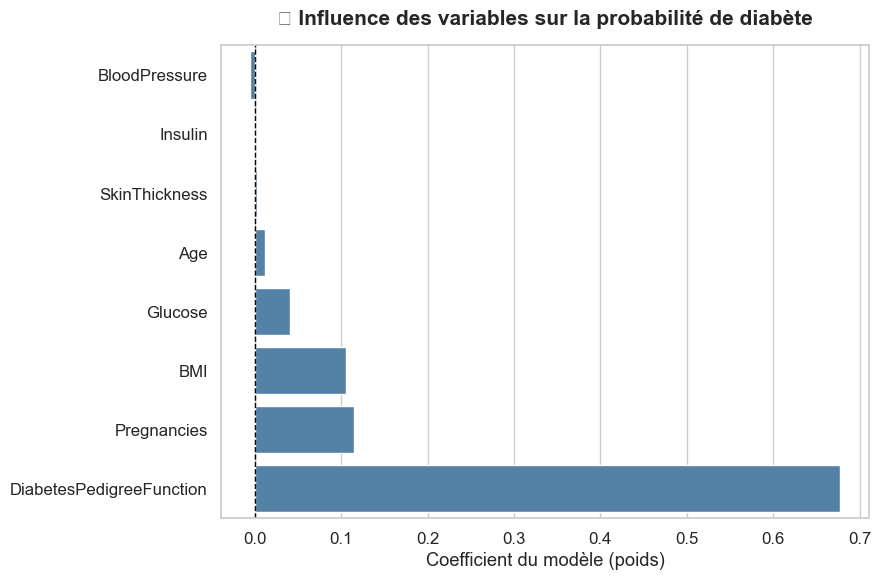

,Variable,Coefficient
2,BloodPressure,-0.005056
4,Insulin,-0.001426
3,SkinThickness,0.002757
7,Age,0.011526
1,Glucose,0.041103
5,BMI,0.105451
0,Pregnancies,0.115250
6,DiabetesPedigreeFunction,0.677300


In [70]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Création du DataFrame des coefficients
coefficients = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=True)

# Définition des couleurs en fonction du signe du coefficient
coefficients["Color"] = coefficients["Coefficient"].apply(lambda x: "crimson" if x > 0 else "steelblue")

# Style visuel moderne
sns.set(style="whitegrid", font_scale=1.1)

plt.figure(figsize=(9,6))
sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Variable",
    hue="Color",            # 👈 utilisation de hue pour colorer selon la colonne
    palette=coefficients["Color"].tolist(),
    dodge=False,
    legend=False            # 👈 suppression de la légende inutile
)

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("📊 Influence des variables sur la probabilité de diabète", fontsize=15, weight="bold", pad=15)
plt.xlabel("Coefficient du modèle (poids)")
plt.ylabel("")
plt.tight_layout()
plt.show()

coefficients[["Variable", "Coefficient"]]



##  Étape 9 – Interprétation des coefficients de la régression logistique

---

###  Coefficients obtenus

| Variable | Coefficient | Interprétation du signe |
|-----------|--------------|-------------------------|
| **BloodPressure** | -0.005 | 🔻 Négatif → légère tendance à réduire le risque |
| **Insulin** | -0.001 | 🔻 Négatif → influence négligeable |
| **SkinThickness** | +0.003 | ⚪ Quasi neutre |
| **Age** | +0.012 | 🔺 Léger effet positif : risque augmente avec l’âge |
| **Glucose** | +0.041 | 🔥 Effet positif modéré à fort : plus la glycémie est élevée, plus le risque augmente |
| **BMI** | +0.105 | 🔥 Fort effet positif : le surpoids augmente significativement le risque |
| **Pregnancies** | +0.115 | ⚠️ Effet positif : plus de grossesses → risque légèrement accru |
| **DiabetesPedigreeFunction** | +0.677 | 🔥🔥 Effet le plus fort : l’hérédité a un impact majeur sur la probabilité de diabète |

---

###  Interprétation détaillée

####  1. Variables les plus influentes
- **DiabetesPedigreeFunction (0.677)** → c’est le **plus grand coefficient** :  
  le risque de diabète **augmente fortement** si le facteur génétique est élevé.  
  > Autrement dit, les personnes ayant des antécédents familiaux ont un risque bien supérieur.  

- **Pregnancies (0.115)** → plus une femme a eu de grossesses, plus le risque de diabète augmente légèrement.  
  Cela peut s’expliquer par le **diabète gestationnel**, souvent précurseur d’un diabète de type 2.  

- **BMI (0.105)** → chaque unité supplémentaire d’indice de masse corporelle augmente la probabilité de diabète.  
  > Le surpoids est donc un **facteur de risque majeur**, confirmant ton analyse exploratoire.  

- **Glucose (0.041)** → plus la glycémie est élevée, plus la probabilité de diabète augmente.  
  C’est une **relation directe et attendue** (le diagnostic de diabète se base sur la glycémie).  

---

####  2. Variables faiblement influentes
- **Age (0.011)** → effet modéré, mais le risque tend à croître avec l’âge.  
- **SkinThickness (0.003)** → influence marginale.  
- **Insulin (-0.001)** → impact quasi nul (forte variabilité).  
- **BloodPressure (-0.005)** → effet négatif léger, probablement non significatif.  

---

###  Synthèse

| Type de facteur | Variables principales | Impact sur le risque de diabète |
|------------------|----------------------|----------------------------------|
| **Génétique** | `DiabetesPedigreeFunction` | 🔥🔥 Très fort |
| **Comportemental / métabolique** | `BMI`, `Glucose` | 🔥 Fort |
| **Démographique** | `Pregnancies`, `Age` | ⚠️ Modéré |
| **Physiologique secondaire** | `Insulin`, `BloodPressure`, `SkinThickness` | ⚪ Faible |

---

###  Conclusion

Ton modèle de régression logistique montre que le **risque de diabète** augmente principalement avec :
1. **le facteur génétique (DiabetesPedigreeFunction)**,  
2. **le surpoids (BMI)**,  
3. **la glycémie élevée (Glucose)**,  
4. et dans une moindre mesure, **l’âge** et **le nombre de grossesses**.

Les autres variables (pression artérielle, insuline, épaisseur cutanée) ont un **effet très limité** sur la prédiction.

---

>  En résumé :  
> ton modèle identifie des relations cohérentes médicalement et statistiquement,  
> en confirmant que le **diabète est fortement influencé par la génétique, le poids et la glycémie.**


##  Étape 10 – Comparaison de modèles : Régression Logistique vs Random Forest


###  Objectif

Comparer les performances de la **régression logistique** (modèle linéaire) avec celles d’un **Random Forest Classifier** (modèle non linéaire et robuste).

Le Random Forest est un ensemble d’arbres de décision qui :
- capture mieux les **relations complexes** entre les variables,
- gère naturellement les **interactions non linéaires**,
- fournit une **mesure d’importance des variables**.


###  Étapes
1. Entraîner un modèle **Random Forest** sur les mêmes données d’entraînement  
2. Évaluer sa **précision** et sa **capacité à détecter les diabétiques (rappel)**  
3. Comparer ses performances avec la **régression logistique**  
4. Visualiser les **importances des variables**




 Précision du Random Forest : 0.75

 Rapport de classification :
               precision    recall  f1-score   support

           0       0.79      0.83      0.81       100
           1       0.65      0.59      0.62        54

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.72       154
weighted avg       0.74      0.75      0.74       154



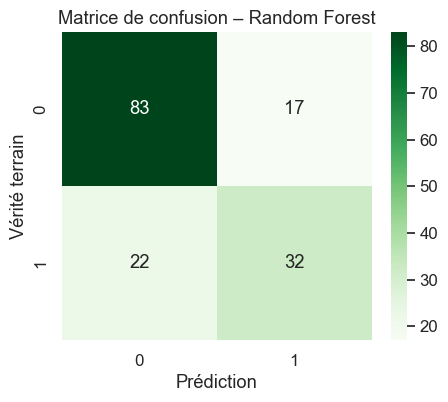

In [71]:

###  Code – Modélisation du Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Entraînement du modèle Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200, 
    random_state=42, 
    class_weight='balanced'   #  corrige le déséquilibre entre classes
)
rf_model.fit(X_train, y_train)

# Prédictions
rf_pred = rf_model.predict(X_test)

# Évaluation
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_report = classification_report(y_test, rf_pred)
rf_cm = confusion_matrix(y_test, rf_pred)

print(f" Précision du Random Forest : {rf_accuracy:.2f}")
print("\n Rapport de classification :\n", rf_report)

# Matrice de confusion
plt.figure(figsize=(5,4))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens')
plt.title("Matrice de confusion – Random Forest")
plt.xlabel("Prédiction")
plt.ylabel("Vérité terrain")
plt.show()


C:\Users\Nassima.OUKHELIFA\AppData\Local\Temp\ipykernel_51500\889185188.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Variable", data=importances, palette="YlGn")


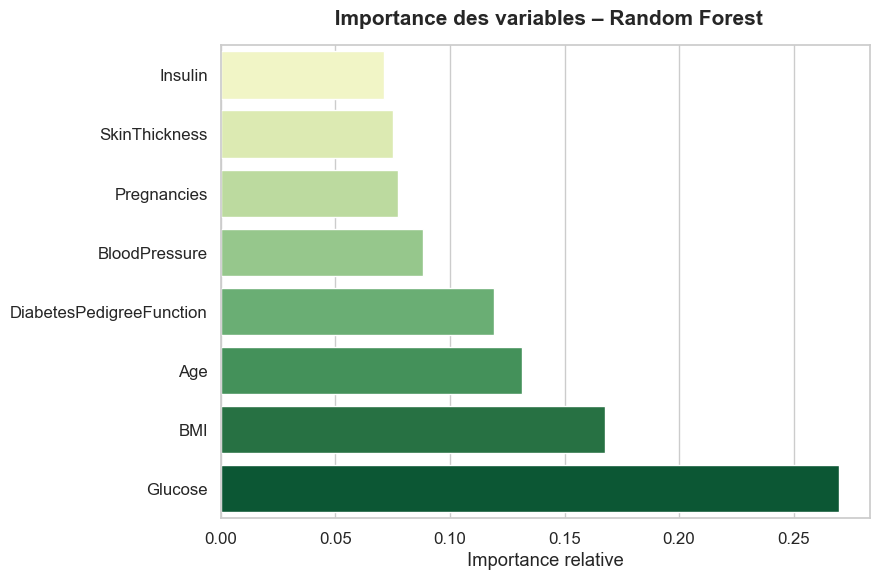

,Variable,Importance
4,Insulin,0.071263
3,SkinThickness,0.074937
0,Pregnancies,0.077346
2,BloodPressure,0.088166
6,DiabetesPedigreeFunction,0.119161
7,Age,0.131439
5,BMI,0.167638
1,Glucose,0.270049


In [72]:
# Extraction des importances
importances = pd.DataFrame({
    "Variable": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=True)

# Visualisation
plt.figure(figsize=(9,6))
sns.barplot(x="Importance", y="Variable", data=importances, palette="YlGn")
plt.title(" Importance des variables – Random Forest", fontsize=15, weight="bold", pad=15)
plt.xlabel("Importance relative")
plt.ylabel("")
plt.tight_layout()
plt.show()

importances
